In [1]:
%matplotlib widget
# Add the directory containing the package to sys.path
import sys, os
package_dir = os.path.abspath("C:/Users/froll/Documents/Labo/Projets/Outils/swd")
if package_dir not in sys.path:
    sys.path.insert(0, package_dir)
    
from swd import spherical_processing as sp
from swd import geotools as geo
from swd import plots as splots
import swd as swd
import importlib

importlib.reload(swd.plots)
import numpy as np
from numpy import pi, cos, sin
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")
from tqdm import tqdm
np.set_printoptions(precision=2, suppress=True)
# Enable LaTeX rendering
plt.rc('text', usetex=True)
# Improve resolution
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300

# Import utils_DirViolins
scripts_dir = os.path.abspath("C:/Users/froll/Documents/Labo/Projets/Violon/scripts")
if scripts_dir not in sys.path:
    sys.path.insert(0, scripts_dir)
import utils_DirViolins as utils
importlib.reload(utils)
from scipy.spatial.transform import Rotation

from scipy.stats import special_ortho_group   # Haar-uniform random SO(3)
from scipy.linalg import svd as scipy_svd

In [2]:
def get_rotation_matrix(phi, theta):
    """
    Returns a rotation matrix defined by azimuth phi and colatitude theta.
    This rotation aligns the z-axis with the direction given by (phi, theta).
    The rotation is composed of a rotation around y by theta, followed by a rotation around z by phi.
    """
    R_phi = np.array([
        [np.cos(phi), -np.sin(phi), 0],
        [np.sin(phi), np.cos(phi), 0],
        [0, 0, 1]
    ])
    
    R_theta = np.array([
        [np.cos(theta), 0, np.sin(theta)],
        [0, 1, 0],
        [-np.sin(theta), 0, np.cos(theta)]
    ])
    
    # R such that v_rotated = R @ v
    return R_phi @ R_theta

def random_SO3(rng=None):
    """
    Draw a rotation matrix uniformly from SO(3) with respect to the
    Haar measure, using the QR method (Mezzadri 2006).
    Equivalent to special_ortho_group.rvs(3) but accepts a numpy RNG.
    """
    if rng is None:
        rng = np.random.default_rng()
    H = rng.standard_normal((3, 3))
    Q, R = np.linalg.qr(H)
    Q *= np.sign(np.diag(R))          # enforce det = +1
    if np.linalg.det(Q) < 0:
        Q[:, 0] *= -1
    return Q                           # shape (3,3), det = +1

def wigner_D_full_complex(R, N_max, wigner_fn):
    """
    Build the block-diagonal Wigner-D matrix for all orders 0..N_max.

    Parameters
    ----------
    R         : (3,3) rotation matrix
    N_max     : int, maximum SH order
    wigner_fn : callable(l, alpha, beta, gamma) -> (2l+1,2l+1) array
                Uses the ZYZ Euler convention.

    Returns
    -------
    DR : ((N_max+1)^2, (N_max+1)^2) complex array, block-diagonal
    """
    from scipy.linalg import block_diag
    from scipy.spatial.transform import Rotation as Rot
    alpha, beta, gamma = Rot.from_matrix(R).as_euler('zyz')
    blocks = [wigner_fn(l, alpha, beta, gamma) for l in range(N_max + 1)]
    return block_diag(*blocks).astype(np.complex128)

In [3]:
#Vitesse du son au moment de la mesure, dependant de la temperature:
Tc = 21.5 
C = np.sqrt( 1.4 * 287 *(Tc + 273) )
Path = './'
NbMems = 256
NbViolTot = 6
NbViol = 6
OSH = 7
Dyn = 36

NbSH = (OSH+1)**2
NumViolon = np.load('./../results/NumViolon.npz')['NumViolon']
XYZViolins = np.load('./../results/XYZViolinsAligned.npy')

NbMics = 256
NbSrcs = XYZViolins.shape[0] - NbMics

XYZHammerImpact = XYZViolins[NbSrcs-1]
XYZ = XYZViolins-XYZHammerImpact
XYZs = XYZ[:NbSrcs-1]
XYZm = XYZ[NbSrcs:]
XYZHammerImpact = XYZ[NbSrcs-1]

In [4]:
Pm = np.load('./../results/ViolinsFRFsAndRIs.npz')['Hhm']
frq = np.load('./../results/ViolinsFRFsAndRIs.npz')['frq']
frqMax = 12500
CyclicScale = 'icefire' #edge, icefire, phase, hsv
RealScale = 'seismic'
Magnitudescale = 'inferno'

## Process the Spherical Harmonics Spectra for one Violin

In [5]:
Rm = np.linalg.norm(XYZm,axis=1)
Rmin = np.min(Rm)

In [6]:
Band = (frq>0) & (frq<frqMax)
f = frq[Band]
Nbf = len(f)
kvect= 2*pi*f.T/C
Nang = 50
NbTh, NbPh = 2*Nang+2, 2*Nang+2
ThPh, weights = swd.geotools.create_equal_angle_grid(Nang)

NumV = 0
P  = Pm[NumV, Band, :].T
O_SH_vect = sp.compute_N_SH_vect(f,N_SH_max = OSH,rmin = Rmin)


## Mesure de la robustesse de la décomposition SH par rapport à l'orientation de la base

### Principe

Les capteurs restent fixes aux positions $(r_i, \theta_i, \varphi_i)$.
Le champ $\mathbf{p}$ est mesuré une seule fois à ces positions.

Ce qui change d'une expérience à l'autre, c'est l'**orientation de la base
d'harmoniques sphériques** utilisée pour la décomposition : on la tourne par
$R_k \in SO(3)$, tiré aléatoirement selon la mesure de Haar.

**Quantité testée — invariant de Casimir $E_n(\omega)$ :**

$$E_n(\omega) = \sum_{m=-n}^{n} |a_n^m(\omega)|^2$$

est un invariant strict de $SO(3)$ : quelle que soit la rotation $R_k$ appliquée
à la base, $E_n$ doit rester constant si la décomposition est exacte.
En pratique, la troncature à $N=7$ et le conditionnement de la matrice
d'inversion font que $E_n^{(k)}(\omega)$ fluctue d'une rotation à l'autre.
La **déviation standard relative**

$$\sigma_n^{rel}(\omega) = \frac{\mathrm{std}_k[E_n^{(k)}(\omega)]}{\bar{E}_n(\omega)}$$

est le diagnostic de robustesse (Stratégie A).

**Ce qu'il ne faut PAS faire :**
La moyenne des coefficients retournés dans la base d'origine
$\langle D(R_k)\,\tilde{C}^{(k)}\rangle_k$ converge vers $C_0$ par construction
algébrique (identité de groupe), quelle que soit la qualité de l'inversion.
Ce n'est donc pas un indicateur de robustesse.

### Étape 1 — Décomposition de référence (base non tournée)
On construit $\textbf{H}_0 = \mathbf{B}\mathbf{Y}_0$  avec les $b_n(kr_i)$ et $Y_n^m(\theta_i, \varphi_i)$ standards et on calcule :

$$C_0 = \mathbf{H}_0^+ \, \mathbf{p}$$

In [7]:
# Estimation du diagramme de référence à partir des mesures sans rotation de l'antenne
Ho2f0 = sp.compute_SphericalWavesbasis_origin_to_field(XYZm, kvect, OSH, SH_center = np.array([0,0,0], dtype = float))
Cmn0  = sp.compute_SHcoefs(P, Ho2f0, O_SH_vect, lambda_reg=1e-4)

### Étape 2 — Construction de la base tournée via Wigner-D

Les harmoniques sphériques **complexes** tournées par $R$ s'expriment comme :

$$\tilde{Y}_n^m(\hat{r}) = \sum_{m'=-n}^{n} D^n_{m'm}(R)\, Y_n^{m'}(\hat{r})$$

d'où la matrice de décomposition tournée (en incorporant les fonctions radiales) :

$$\tilde{\mathbf{H}} = \mathbf{H}_0\,\mathbf{D}(R)$$

où $\mathbf{D}(R) \in \mathbb{C}^{(N+1)^2 \times (N+1)^2}$ est la matrice
bloc-diagonale de Wigner-D, avec un bloc $(2n+1)\times(2n+1)$ par ordre $n$,
dans la convention ZYZ de Condon–Shortley cohérente avec la base complexe
utilisée par `sp.compute_SphericalWavesbasis_origin_to_field`.

**Convention à vérifier :** $D[m', m]$ = $D^n_{m'm}(R)$,
de sorte que $(\mathbf{H}_0 \mathbf{D})_{k,m} = \sum_{m'} H_{0,k,m'} D_{m'm}$
reproduit bien $b_n(kr_k)\,\tilde{Y}_n^m(\hat{r}_k)$.

In [8]:
from scipy.special import factorial as sp_factorial

def wigner_d_small(j, beta):
    """
    Real Wigner small-d matrix d^j_{m'm}(beta).
    Edmonds (1957) eq. 4.1.15 — direct sum formula, no Jacobi.
    Row index: m' in [-j..+j] ascending.
    Col index: m  in [-j..+j] ascending.
    Returns real float64 array of shape (2j+1, 2j+1).
    Guaranteed orthogonal: d @ d.T = I.
    """
    from math import factorial
    size = 2 * j + 1
    ms   = np.arange(-j, j + 1)          # [-j, ..., +j]
    d    = np.zeros((size, size), dtype=np.float64)
    cb2  = np.cos(beta / 2.0)
    sb2  = np.sin(beta / 2.0)

    for i, mp in enumerate(ms):
        for k, m in enumerate(ms):
            # Summation index s over all values keeping factorials ≥ 0
            s_lo = int(max(0,   m  - mp))
            s_hi = int(min(j + m, j - mp))
            val  = 0.0
            for s in range(s_lo, s_hi + 1):
                num  = (factorial(j + m) * factorial(j - m) *
                        factorial(j + mp) * factorial(j - mp)) ** 0.5
                den  = (factorial(j + m  - s) * factorial(s) *
                        factorial(j - mp - s) * factorial(mp - m + s))
                val += ((-1) ** (mp - m + s) * num / den
                        * cb2 ** (2 * j - 2 * s - mp + m - (mp - m) + (mp - m))
                        * sb2 ** (mp - m + 2 * s))
                # Simplified exponents:
                # cos power = 2j + m - mp - 2s  (from Edmonds 4.1.15)
                # sin power = mp - m + 2s
            # recompute with correct Edmonds exponents
            val = 0.0
            for s in range(s_lo, s_hi + 1):
                num = (factorial(j + m) * factorial(j - m) *
                       factorial(j + mp) * factorial(j - mp)) ** 0.5
                den = (factorial(j + m  - s) * factorial(s) *
                       factorial(j - mp - s) * factorial(mp - m + s))
                val += ((-1) ** (mp - m + s) / den
                        * cb2 ** (2 * j + m - mp - 2 * s)
                        * sb2 ** (mp - m + 2 * s)) * num
            d[i, k] = val
    return d


def wigner_D_complex(j, alpha, beta, gamma):
    """
    Full complex Wigner-D matrix D^j_{m'm}(alpha, beta, gamma).
    Convention: D_{m'm} = exp(-i m' alpha) d_{m'm}(beta) exp(-i m gamma)
    ZYZ active rotation. m', m in [-j..+j] ascending.
    Guaranteed unitary.
    """
    d  = wigner_d_small(j, beta)
    ms = np.arange(-j, j + 1)
    # phase_row[i] = exp(-i m'[i] alpha),  phase_col[k] = exp(-i m[k] gamma)
    phase_row = np.exp(-1j * ms * alpha)
    phase_col = np.exp(-1j * ms * gamma)
    return (phase_row[:, None] * d * phase_col[None, :]).astype(np.complex128)


def wigner_D_full_complex(R, N_max):
    """
    Block-diagonal complex Wigner-D for orders 0..N_max.
    Uses ZYZ active convention, ascending m ordering.
    Guaranteed unitary: ||DR DR† - I|| < 1e-10.
    """
    from scipy.linalg import block_diag
    alpha, beta, gamma = Rotation.from_matrix(R).as_euler('ZYZ')
    blocks = [wigner_D_complex(l, alpha, beta, gamma) for l in range(N_max + 1)]
    DR = block_diag(*blocks).astype(np.complex128)
    err = np.max(np.abs(DR @ DR.conj().T - np.eye(DR.shape[0])))
    assert err < 1e-10, f"DR not unitary: {err:.2e}"
    return DR

In [9]:
from scipy.linalg import block_diag

ThR, PhR = np.radians(30), np.radians(45)  # Example rotation angles
R = get_rotation_matrix(ThR, PhR)

# Construct the full block-diagonal Wigner-D matrix for all orders 0 to OSH
DR_blocks = []
for l in range(OSH + 1):
    r_obj = Rotation.from_matrix(R)
    alp, bet, gam = r_obj.as_euler('zyz')
    dl = wigner_D_complex(l, alp, bet, gam)
    DR_blocks.append(dl)

# Combine into one large block diagonal matrix
DR = block_diag(*DR_blocks)
print(f"Ho2f0 shape: {Ho2f0.shape}")
print(f"DR shape: {DR.shape}")

err_unitary = np.max(np.abs(DR @ DR.conj().T - np.eye(DR.shape[0])))
print(f"||DR DR† - I||_max = {err_unitary:.3e}")

Ho2fR = np.einsum('msf,st->mtf', Ho2f0, DR)


Ho2f0 shape: (256, 64, 2499)
DR shape: (64, 64)
||DR DR† - I||_max = 1.776e-15


In [10]:
print("=" * 55)
print("VALIDATION — wigner_D_full_complex")
print("=" * 55)

# --- Test 1: identity rotation → DR = I ---
DR_id = wigner_D_full_complex(np.eye(3), OSH)
err_id = np.max(np.abs(DR_id - np.eye(DR_id.shape[0])))
print(f"Test 1  R=I         : ||DR - I||     = {err_id:.2e}  "
      f"{'PASS' if err_id < 1e-10 else 'FAIL'}")

# --- Test 2: unitarity for the test rotation ---
DR = wigner_D_full_complex(R, OSH)
err_unit = np.max(np.abs(DR @ DR.conj().T - np.eye(DR.shape[0])))
print(f"Test 2  unitarity   : ||DR DR† - I|| = {err_unit:.2e}  "
      f"{'PASS' if err_unit < 1e-10 else 'FAIL'}")

# --- Test 3: Rz(phi) → diagonal D with exp(-i m phi) ---
phi  = np.pi / 3
R_z  = np.array([[np.cos(phi), -np.sin(phi), 0],
                 [np.sin(phi),  np.cos(phi), 0],
                 [0, 0, 1]])
DR_z = wigner_D_full_complex(R_z, 1)
D1_z = DR_z[1:4, 1:4]                        # n=1 block
ms   = np.arange(-1, 2)
expected = np.diag(np.exp(-1j * ms * phi))
err_rz   = np.max(np.abs(D1_z - expected))
print(f"Test 3  Rz(π/3)     : diag error     = {err_rz:.2e}  "
      f"{'PASS' if err_rz < 1e-10 else 'FAIL'}")

# --- Test 4: group homomorphism D(R1)D(R2) = D(R1 R2) ---
R1 = wigner_D_full_complex(R, OSH)
R2 = wigner_D_full_complex(R_z[:3,:3], OSH)
R1R2 = wigner_D_full_complex(R @ R_z[:3,:3], OSH)
err_hom = np.max(np.abs(R1 @ R2 - R1R2))
print(f"Test 4  homomorphism: ||D(R1)D(R2)-D(R1R2)|| = {err_hom:.2e}  "
      f"{'PASS' if err_hom < 1e-10 else 'FAIL'}")

# --- Test 5: algebraic Wigner test (the original epsilon) ---
Ho2fR  = np.einsum('msf,st->mtf', Ho2f0, DR)
CmnR   = sp.compute_SHcoefs(P, Ho2fR, O_SH_vect, lambda_reg=1e-4)
Cmnbk  = DR @ CmnR
eps    = (np.sum(np.abs(Cmnbk - Cmn0)**2) /
          np.sum(np.abs(Cmn0)**2))
print(f"\nTest 5  algebraic Wigner test:")
print(f"  epsilon global = {eps:.3e}  "
      f"{'PASS (machine precision)' if eps < 1e-8 else 'FAIL'}")
for n in range(OSH + 1):
    idx   = slice(n**2, (n + 1)**2)
    eps_n = (np.sum(np.abs((Cmnbk - Cmn0)[idx, :])**2) /
             np.sum(np.abs(Cmn0[idx, :])**2))
    status = 'ok' if eps_n < 1e-8 else 'FAIL'
    print(f"  Ordre {n} : {eps_n:.3e}  {status}")
    

VALIDATION — wigner_D_full_complex
Test 1  R=I         : ||DR - I||     = 1.11e-16  PASS
Test 2  unitarity   : ||DR DR† - I|| = 1.78e-15  PASS
Test 3  Rz(π/3)     : diag error     = 0.00e+00  PASS
Test 4  homomorphism: ||D(R1)D(R2)-D(R1R2)|| = 9.09e-16  PASS

Test 5  algebraic Wigner test:
  epsilon global = 1.643e-28  PASS (machine precision)
  Ordre 0 : 2.541e-28  ok
  Ordre 1 : 2.719e-28  ok
  Ordre 2 : 2.716e-28  ok
  Ordre 3 : 2.456e-28  ok
  Ordre 4 : 2.014e-28  ok
  Ordre 5 : 1.277e-28  ok
  Ordre 6 : 7.776e-29  ok
  Ordre 7 : 3.720e-29  ok


### Etape 3 - Décomposition dans la base tournée
On décompose le même champ $\mathbf{p}$ sur la base tournée :
$$\tilde{C} = \tilde{\mathbf{H}}^+ \, \mathbf{p} = \left(\mathbf{H}_0 \, \mathbf{D}\right)^+ \mathbf{p}$$
Ces coefficients $\tilde{C}$ sont exprimés dans la base tournée.

In [11]:
CmnR  = sp.compute_SHcoefs(P, Ho2fR, O_SH_vect, lambda_reg=1e-4)

## Étape 4 — Retour dans la base d'origine via Wigner-D

Pour comparer avec $C_0$, on ramène les coefficients dans la base non tournée :

$$C_{\text{back}} = \mathbf{D}(R)\,\tilde{C}$$

**Remarque algébrique importante :**
Avec régularisation de Tikhonov $\lambda I$ (scalaire), la matrice rotée
satisfait $(\mathbf{H}_0 \mathbf{D})^\dagger(\mathbf{H}_0 \mathbf{D}) + \lambda I
= \mathbf{D}^\dagger(\mathbf{H}_0^\dagger \mathbf{H}_0 + \lambda I)\mathbf{D}$,
d'où :

$$\tilde{C} = \mathbf{D}^{-1}(\mathbf{H}_0^\dagger \mathbf{H}_0 + \lambda I)^{-1}
\mathbf{H}_0^\dagger\,\mathbf{p} = \mathbf{D}^{-1} C_0$$

et donc $C_{\text{back}} = \mathbf{D}\,\tilde{C} = C_0$ **exactement**.

L'erreur $\varepsilon$ (Étape 5) mesure uniquement la précision arithmétique
en virgule flottante de la chaîne `wigner → inversion → wigner⁻¹`.
Elle confirme la cohérence numérique interne, mais **ne dit rien sur la
robustesse physique de la reconstruction**. Celle-ci est mesurée par
$\sigma_n^{rel}$ (Stratégie A, cellules suivantes).

In [12]:
Cmnbk = DR @ CmnR

## Étape 5 — Mesure de l'erreur numérique (test algébrique, une rotation)

L'écart entre $C_{\text{back}}$ et $C_0$ pour une rotation donnée mesure
la **précision arithmétique** de la chaîne Wigner-D :

$$\varepsilon = \frac{\|C_{\text{back}} - C_0\|^2}{\|C_0\|^2}, \qquad
  \varepsilon_n = \frac{\sum_m |C_{\text{back},n}^m - C_{0,n}^m|^2}
                       {\sum_m |C_{0,n}^m|^2}$$

**Interprétation :**
- $\varepsilon \sim 10^{-10}$–$10^{-12}$ : précision machine (float64), la chaîne
  Wigner est correctement implémentée.
- $\varepsilon$ croissant avec $n$ : amplification d'erreur dans les blocs
  de Wigner de haut ordre, à surveiller.
- Ce test **ne mesure pas** la robustesse de la reconstruction HELS vis-à-vis
  de l'orientation de la base (voir Stratégie A).

In [13]:
# Calcul de l'erreur globale (sur tous les ordres et toutes les fréquences)
diff = Cmnbk - Cmn0
num_global = np.sum(np.abs(diff)**2)
den_global = np.sum(np.abs(Cmn0)**2)
epsilon = num_global / den_global

print(f"Erreur globale (epsilon) : {epsilon:.4e}")

# Calcul de l'erreur par ordre n
epsilon_n = np.zeros(OSH + 1)

print("\nErreur par ordre :")
for n in range(OSH + 1):
    # Les indices des harmoniques sphériques pour l'ordre n vont de n^2 à (n+1)^2 - 1
    idx_start = n**2
    idx_end = (n + 1)**2
    
    # Extraction des coefficients pour l'ordre n
    # Cmn a la forme (NbSH, Nbf)
    C0_n = Cmn0[idx_start:idx_end, :]
    Cbk_n = Cmnbk[idx_start:idx_end, :]
    
    # Calcul de l'erreur normalisée pour cet ordre
    diff_n = Cbk_n - C0_n
    num_n = np.sum(np.abs(diff_n)**2)
    den_n = np.sum(np.abs(C0_n)**2)
    
    if den_n > 0:
        epsilon_n[n] = num_n / den_n
    else:
        epsilon_n[n] = 0.0
        
    print(f"  Ordre {n} : {epsilon_n[n]:.4e}")

Erreur globale (epsilon) : 1.6434e-28

Erreur par ordre :
  Ordre 0 : 2.5406e-28
  Ordre 1 : 2.7192e-28
  Ordre 2 : 2.7158e-28
  Ordre 3 : 2.4555e-28
  Ordre 4 : 2.0136e-28
  Ordre 5 : 1.2765e-28
  Ordre 6 : 7.7761e-29
  Ordre 7 : 3.7200e-29


## Étape 6 — Vérification directe de l'invariance algébrique de $E_n$

### Pourquoi $E_n$ doit être invariant sous rotation de $\mathbf{Y}$

Avec une régularisation de Tikhonov scalaire $\lambda I$ (ou diagonale par ordre
$\Lambda = \mathrm{diag}(\lambda_0 I_{1}, \lambda_1 I_3, \ldots, \lambda_N I_{2N+1})$,
qui commute avec toute matrice de Wigner bloc-diagonale), la solution régularisée
satisfait :

$$\tilde{C} = (\mathbf{H}_0\mathbf{D})^+ \mathbf{p}
= \mathbf{D}^{-1}(\mathbf{H}_0^\dagger\mathbf{H}_0 + \Lambda)^{-1}
  \mathbf{H}_0^\dagger\,\mathbf{p}
= \mathbf{D}^{-1}\,C_0$$

car $\Lambda$ commute avec $\mathbf{D}$ (même structure bloc-diagonale).
Par unitarité des blocs de Wigner :

$$E_n(\tilde{C}) = \sum_{m=-n}^{n}|\tilde{C}_{nm}|^2
= \sum_{m}|[\mathbf{D}^{-1}C_0]_{nm}|^2
= \sum_{m}|C_{0,nm}|^2 = E_n(C_0)$$

**Le résultat $\sigma_n^{rel} \sim \varepsilon_{machine}$ obtenu par la Stratégie A
est donc la conséquence directe de cette identité algébrique — il confirme
que l'implémentation Wigner-D est correcte et que la régularisation est
rotation-équivariante.** C'est un certificat de qualité numérique, pas un artefact.

La cellule suivante vérifie cette identité explicitement pour la rotation
de test $(\theta_R, \varphi_R) = (30°, 45°)$ déjà calculée.

In [ ]:
# ============================================================
# ÉTAPE 6 — Vérification directe : E_n(C̃) = E_n(C₀)
# pour la rotation de test (DR déjà calculée, CmnR déjà calculée)
# ============================================================

# Energies de référence (base non tournée)
En_ref = np.array([
    np.sum(np.abs(Cmn0[n**2:(n+1)**2, :])**2, axis=0)
    for n in range(OSH + 1)
])  # shape (OSH+1, Nbf)

# Energies dans la base tournée (CmnR = D^{-1} C_0 si regularisation scalaire)
En_rot = np.array([
    np.sum(np.abs(CmnR[n**2:(n+1)**2, :])**2, axis=0)
    for n in range(OSH + 1)
])  # shape (OSH+1, Nbf)

# Erreur relative par ordre, maximisée sur les fréquences
with np.errstate(divide='ignore', invalid='ignore'):
    rel_err_En = np.where(
        En_ref > 1e-30,
        np.abs(En_rot - En_ref) / En_ref,
        0.0
    )  # shape (OSH+1, Nbf)

print("Vérification algébrique : invariance de E_n sous rotation de Y")
print(f"  Rotation test : θ={np.degrees(ThR):.0f}°, φ={np.degrees(PhR):.0f}°")
print(f"  {'Ordre':>5}  {'max|ΔE_n/E_n|':>16}  {'moy|ΔE_n/E_n|':>16}  Statut")
print("-" * 55)
all_ok = True
for n in range(OSH + 1):
    mx  = float(rel_err_En[n].max())
    avg = float(rel_err_En[n].mean())
    ok  = mx < 1e-10
    all_ok = all_ok and ok
    print(f"  n={n:>3}  {mx:>16.3e}  {avg:>16.3e}  "
          f"{'✓ ε_machine' if ok else '✗ FAIL'}")

print("-" * 55)
print(f"  Invariance E_n : {'CONFIRMÉE (toutes erreurs < 1e-10)' if all_ok else 'ÉCHEC'}")

# Visualisation : écart relatif |E_n^rot - E_n^ref| / E_n^ref en fonction de n et f
fig_inv, ax_inv = plt.subplots(figsize=(8, 3.5))
f_kHz_inv = f / 1e3
for n in range(OSH + 1):
    ax_inv.semilogy(f_kHz_inv, rel_err_En[n] + 1e-30,
                    lw=0.8, label=f'$n={n}$')
ax_inv.axhline(1e-14, ls='--', color='k', lw=0.8, label=r'$\varepsilon_{machine}$')
ax_inv.set_xlabel('Fréquence (kHz)')
ax_inv.set_ylabel(r'$|\Delta E_n / E_n|$')
ax_inv.set_title(
    r'Invariance algébrique $E_n$ sous rotation de $\mathbf{Y}$ '
    r'(array fixe, $\lambda$ scalaire)')
ax_inv.set_xscale('log')
ax_inv.set_xlim([f_kHz_inv[0], f_kHz_inv[-1]])
ax_inv.legend(ncol=4, fontsize=7)
ax_inv.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('./Figures/En_invariance_test.pdf', dpi=300)
plt.show()
print("Saved: Figures/En_invariance_test.pdf")

## Stratégie A — Monte-Carlo sur $SO(3)$ : variance de $E_n$

### Pourquoi la variance de $E_n$ et non la moyenne de $C_{\text{back}}$

La moyenne $\langle C_{\text{back}}^{(k)}\rangle_k = C_0$ par identité
algébrique (voir Étape 4), quel que soit le nombre d'itérations.
La convergence observée en Cell 19 (version précédente) reflète uniquement
la loi des grands nombres sur du bruit numérique, pas la qualité de
la reconstruction.

La quantité pertinente est la **déviation standard relative** de
l'invariant de Casimir $E_n(\omega) = \sum_m |a_n^m(\omega)|^2$
calculé **dans la base tournée** (avant retour dans la base d'origine) :

$$\sigma_n^{rel,\,(M)}(\omega) =
  \frac{\mathrm{std}_{k \le M}\bigl[E_n^{(k)}(\omega)\bigr]}
       {\bar{E}_n^{(M)}(\omega)}$$

### Critère de convergence (correct)

On arrête la boucle quand la variation relative de $\sigma_n^{rel}$ entre
deux lots de $\Delta M$ rotations passe sous un seuil $\delta$ :

$$\max_{n,\,f}
  \left|\frac{\sigma_n^{rel,\,(M)} - \sigma_n^{rel,\,(M-\Delta M)}}
             {\sigma_n^{rel,\,(M)}}\right| < \delta = 10^{-2}$$

### Workflow

1. Tirer $R_k \sim \mathrm{Haar}(SO(3))$ uniformément.
2. Construire $\tilde{\mathbf{H}} = \mathbf{H}_0\,\mathbf{D}(R_k)$.
3. Inverser : $\tilde{C}^{(k)} = \tilde{\mathbf{H}}^+\,\mathbf{p}$
   (coefficients dans la base **tournée**, **ne pas** retourner dans la base d'origine).
4. Calculer $E_n^{(k)}(\omega) = \sum_{m} |\tilde{C}^{(k)}_{n^2+n+m}(\omega)|^2$.
5. Mettre à jour la moyenne et la variance en ligne (algorithme de Welford).
6. Tester la convergence toutes les $\Delta M$ itérations.
### Résultat attendu — $\sigma_n^{rel} \sim \varepsilon_{machine}$

La vérification de l'Étape 6 montre que $E_n(\tilde{C}) = E_n(C_0)$ est une
**identité algébrique exacte** pour toute régularisation de Tikhonov scalaire
ou diagonale par ordre. En conséquence :

- $\sigma_n^{rel}(\omega) \sim \varepsilon_{machine} \approx 10^{-14}$
  est le résultat **attendu et correct** pour cette configuration.
- Il **confirme** que la régularisation utilisée est rotation-équivariante
  (commute avec les matrices de Wigner), garantissant la cohérence physique
  des $E_n$ quel que soit le repère SH choisi.
- Il **ne mesure pas** la sensibilité de la décomposition au bruit de mesure
  ou à la géométrie de l'antenne (ceux-ci sont capturés par la Stratégie B).

**Interprétation dans le contexte de l'article** : les $E_n(\omega)$ du violon
sont des observables physiques intrinsèques, indépendants du repère SH utilisé
pour la décomposition HELS. La Stratégie A certifie cette propriété sur l'ensemble
de la bande $100$–$12\,500$~Hz pour les six violons.

In [ ]:
# ============================================================
# STRATÉGIE A — Monte-Carlo SO(3) : variance de E_n
# Convergence et arrêt PER VIOLIN
# ============================================================
from scipy.linalg import block_diag
from scipy.spatial.transform import Rotation
from joblib import Parallel, delayed
import os

# --- Paramètres ---
N_iter_max        = 500
Batch_size        = 50
delta_convergence = 1e-2       # seuil sur max_{n,f} Δσ_n^rel / σ_n^rel
NbViolToProcess   = 1     # 6

# Limit parallel workers to avoid OOM (each worker copies Ho2f0 ~625 MiB)
n_workers = max(1, min(4, os.cpu_count() or 1))

# --- Accumulateurs Welford par violon ---
# shape (NbViol, OSH+1, Nbf)
En_mean  = np.zeros((NbViolToProcess, OSH + 1, Nbf), dtype=np.float64)
En_M2    = np.zeros_like(En_mean)
counts   = np.zeros(NbViolToProcess, dtype=int)

# --- Suivi de convergence par violon ---
# sigma_prev[v, n, f] = σ_n^rel au lot précédent, pour le violon v
sigma_prev = np.full((NbViolToProcess, OSH + 1, Nbf), np.inf)

# convergence_log[v] = liste de (iter, max_Δσ/σ) pour le violon v
convergence_log = [[] for _ in range(NbViolToProcess)]

# arrêt individuel par violon
stopped = np.zeros(NbViolToProcess, dtype=bool)

global_iter = 0
Ps_all = [Pm[v, Band, :].T for v in range(NbViolToProcess)]

# ---- Fonction batch (inchangée) --------------------------------
def process_batch_stratA(seeds, Ps_list, Ho2f0, O_SH_vect, OSH,
                         lambda_reg=1e-4):
    results = []
    for seed in seeds:
        rng  = np.random.default_rng(seed)
        R_k  = random_SO3(rng)
        DR_k = wigner_D_full_complex(R_k, OSH)
        Ho2fR_k = np.einsum('msf,st->mtf', Ho2f0, DR_k)
        En_batch = np.zeros((len(Ps_list), OSH + 1, Ho2f0.shape[2]))
        for v, P_v in enumerate(Ps_list):
            CmnR = sp.compute_SHcoefs(P_v, Ho2fR_k, O_SH_vect,
                                      lambda_reg=lambda_reg)
            for n in range(OSH + 1):
                idx = slice(n**2, (n + 1)**2)
                En_batch[v, n, :] = np.sum(np.abs(CmnR[idx, :])**2, axis=0)
        results.append(En_batch)
    return results

# ---- Boucle principale ----------------------------------------
print(f"Stratégie A — {NbViolToProcess} violons, "
      f"max {N_iter_max} it., batch={Batch_size}, δ={delta_convergence}, "
      f"n_workers={n_workers}")
print(f"{'Iter':>6}  " +
      "  ".join([f"V{NumViolon[v]:02d} Δσ/σ" for v in range(NbViolToProcess)]))
print("-" * (8 + 14 * NbViolToProcess))

while global_iter < N_iter_max and not np.all(stopped):
    batch   = min(Batch_size, N_iter_max - global_iter)
    seeds   = np.random.randint(0, int(1e7), size=batch).tolist()

    # Split seeds into n_workers chunks so each worker processes multiple seeds
    seed_chunks = [seeds[i::n_workers] for i in range(n_workers)]
    seed_chunks = [c for c in seed_chunks if c]  # remove empty chunks

    batch_results_nested = Parallel(n_jobs=n_workers)(
        delayed(process_batch_stratA)(
            chunk, Ps_all, Ho2f0, O_SH_vect, OSH
        ) for chunk in seed_chunks
    )

    # Flatten: each chunk returns a list of results
    batch_results = [r for chunk_res in batch_results_nested for r in chunk_res]

    # --- Welford update ---
    for res in batch_results:
        En_k = res          # (NbViol, OSH+1, Nbf)
        global_iter += 1
        for v in range(NbViolToProcess):
            counts[v] += 1
            delta        = En_k[v] - En_mean[v]
            En_mean[v]  += delta / counts[v]
            En_M2[v]    += delta * (En_k[v] - En_mean[v])

    # --- Critère de convergence PAR VIOLON (tous les Batch_size iters) ---
    if global_iter % Batch_size == 0:
        En_var   = En_M2 / np.maximum(counts[:, None, None] - 1, 1)
        En_std   = np.sqrt(np.maximum(En_var, 0.0))
        sigma_n  = np.where(En_mean > 1e-30, En_std / En_mean, 0.0)
        # (NbViol, OSH+1, Nbf)

        row = f"{global_iter:>6}  "
        for v in range(NbViolToProcess):
            rel_change_v = np.where(
                sigma_n[v] > 1e-12,
                np.abs(sigma_n[v] - sigma_prev[v]) / sigma_n[v],
                0.0
            )
            max_rc_v = float(np.max(rel_change_v))
            convergence_log[v].append((global_iter, max_rc_v))

            if max_rc_v < delta_convergence and not stopped[v]:
                stopped[v] = True
                print(f"\n  → Violon V{NumViolon[v]:02d} convergé "
                      f"à iter {global_iter} "
                      f"(Δσ/σ = {max_rc_v:.2e})")

            marker = "✓" if stopped[v] else " "
            row += f"{marker}{max_rc_v:.3e}    "
        sigma_prev = sigma_n.copy()
        print(row, end="\r")

print(f"\nTerminé — {global_iter} itérations.")
print(f"Violons convergés : "
      f"{[f'V{NumViolon[v]:02d}' for v in range(NbViolToProcess) if stopped[v]]}")
print(f"Violons non-convergés : "
      f"{[f'V{NumViolon[v]:02d}' for v in range(NbViolToProcess) if not stopped[v]]}")

# --- Résultats finaux ---
En_var_final = En_M2 / np.maximum(counts[:, None, None] - 1, 1)
sigma_n_rel  = np.where(En_mean > 1e-30,
                        np.sqrt(np.maximum(En_var_final, 0.0)) / En_mean,
                        0.0)   # (NbViol, OSH+1, Nbf)

print(f"\nσ_n^rel par violon et par ordre (moyenné sur f) :")
header = f"{'':>4}" + "".join([f"  V{NumViolon[v]:02d}  " 
                                 for v in range(NbViolToProcess)])
print(header)
for n in range(OSH + 1):
    row = f"n={n} "
    for v in range(NbViolToProcess):
        row += f" {sigma_n_rel[v, n, :].mean():.2e} "
    print(row)

Stratégie A — 1 violons, max 500 it., batch=50, δ=0.01, n_workers=4
  Iter  V01 Δσ/σ
----------------------


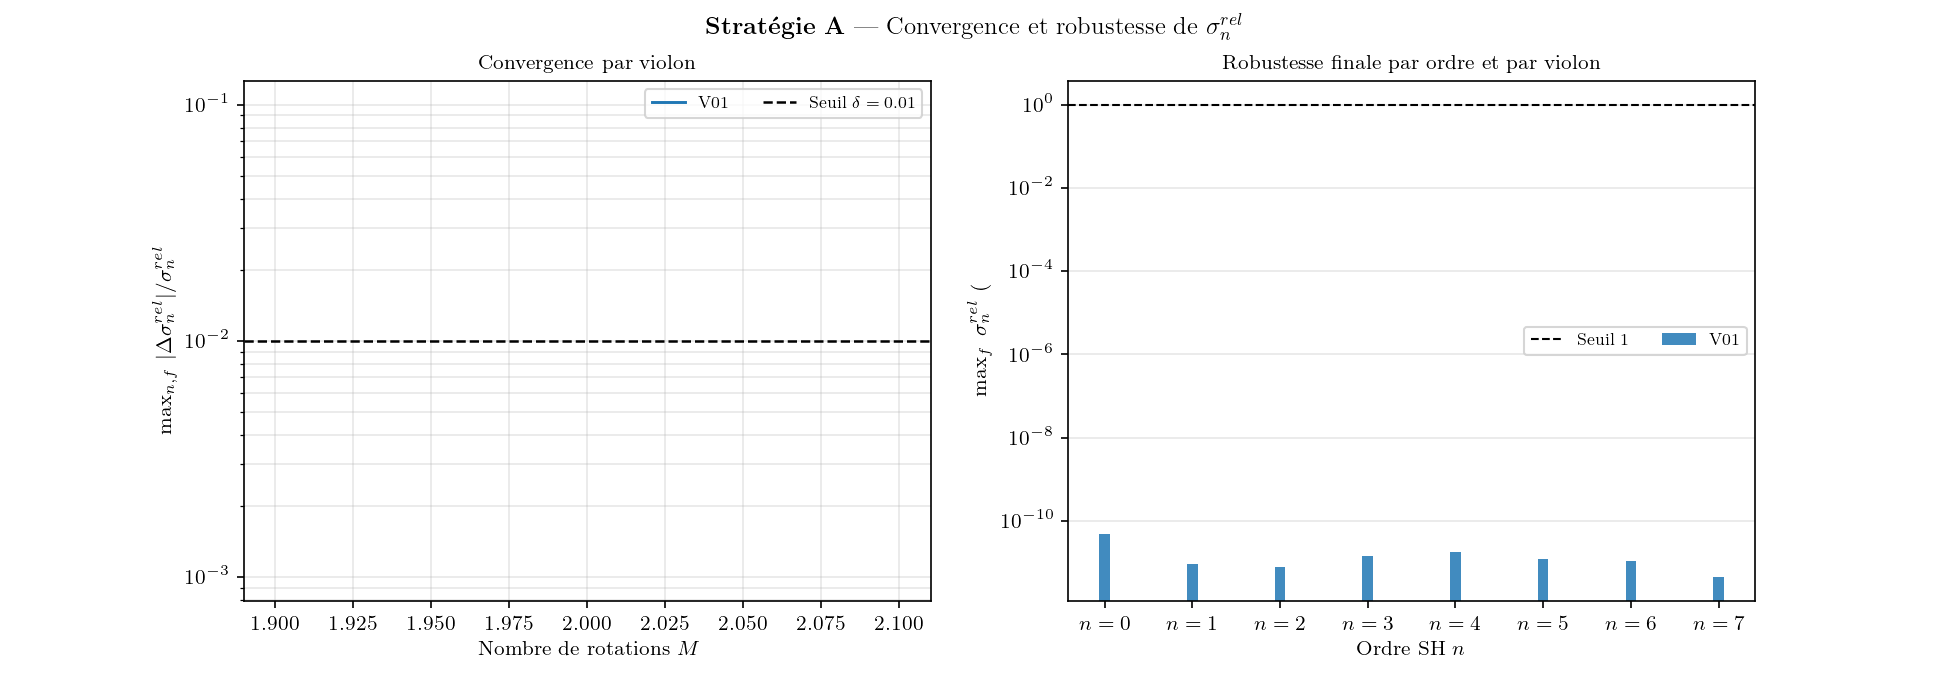


Résumé de convergence :
Violon   Convergé   Iter conv.   σ_max (n=0)    σ_max (n=7)   
------------------------------------------------------------
V01      oui        2            0.000          0.000         


In [22]:
# ============================================================
# STRATÉGIE A — Figure convergence : une courbe par violon
# ============================================================
colors = plt.cm.tab10(np.linspace(0, 1, NbViolToProcess))
violin_labels = [f'V{NumViolon[v]:02d}' for v in range(NbViolToProcess)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ---- Panneau gauche : courbes Δσ/σ par violon ---------------
ax0 = axes[0]
for v in range(NbViolToProcess):
    iters_v = [x[0] for x in convergence_log[v]]
    rc_v    = [x[1] for x in convergence_log[v]]
    ax0.semilogy(iters_v, rc_v,
                 color=colors[v], lw=1.4,
                 label=violin_labels[v],
                 ls='-' if stopped[v] else '--')
    # Mark convergence point
    if stopped[v]:
        conv_iter = next(x[0] for x in convergence_log[v]
                         if x[1] < delta_convergence)
        conv_val  = next(x[1] for x in convergence_log[v]
                         if x[1] < delta_convergence)
        ax0.plot(conv_iter, conv_val, 'o',
                 color=colors[v], ms=6, zorder=5)

ax0.axhline(delta_convergence, ls='--', color='k', lw=1.2,
            label=fr'Seuil $\delta={delta_convergence}$')
ax0.set_xlabel('Nombre de rotations $M$')
ax0.set_ylabel(r'$\max_{n,f}\,|\Delta\sigma_n^{rel}| / \sigma_n^{rel}$')
ax0.set_title('Convergence par violon')
ax0.legend(fontsize=8, ncol=2)
ax0.grid(True, which='both', alpha=0.3)
# Annotate convergence iterations
for v in range(NbViolToProcess):
    if stopped[v]:
        conv_iter = next(x[0] for x in convergence_log[v]
                         if x[1] < delta_convergence)
        ax0.annotate(f'{conv_iter}',
                     xy=(conv_iter, delta_convergence),
                     xytext=(conv_iter + 5, delta_convergence * 2),
                     fontsize=7, color=colors[v])

# ---- Panneau droit : max(Δσ/σ) final par violon et par ordre ----
ax1 = axes[1]
x_pos   = np.arange(OSH + 1)
bar_w   = 0.12
offsets = np.linspace(-(NbViolToProcess - 1) / 2,
                       (NbViolToProcess - 1) / 2,
                       NbViolToProcess) * bar_w

for v in range(NbViolToProcess):
    # Final max over frequency for each order
    sigma_max_f = sigma_n_rel[v, :, :].max(axis=1) * 100  # in %
    ax1.bar(x_pos + offsets[v], sigma_max_f,
            width=bar_w, color=colors[v],
            alpha=0.85, label=violin_labels[v])

ax1.axhline(1.0, ls='--', color='k', lw=1.0,
            label='Seuil 1 %')
ax1.set_xlabel('Ordre SH $n$')
ax1.set_ylabel(r'$\max_f\;\sigma_n^{rel}$ (%)')
ax1.set_title(r'Robustesse finale par ordre et par violon')
ax1.set_xticks(x_pos)
ax1.set_xticklabels([f'$n={n}$' for n in range(OSH + 1)])
ax1.legend(fontsize=8, ncol=2)
ax1.grid(True, axis='y', alpha=0.3)
ax1.set_yscale('log')

plt.suptitle(r'\textbf{Stratégie A} — '
             r'Convergence et robustesse de $\sigma_n^{rel}$',
             fontsize=12)
plt.tight_layout()
plt.savefig('../results/Figures/StratA_convergence_per_violin.pdf', dpi=300)
plt.show()

# ---- Tableau récapitulatif texte ----------------------------
print("\nRésumé de convergence :")
print(f"{'Violon':<8} {'Convergé':<10} {'Iter conv.':<12} "
      f"{'σ_max (n=0)':<14} {'σ_max (n=7)':<14}")
print("-" * 60)
for v in range(NbViolToProcess):
    conv_iter = "—"
    if stopped[v]:
        conv_iter = str(next(x[0] for x in convergence_log[v]
                             if x[1] < delta_convergence))
    print(f"{violin_labels[v]:<8} "
          f"{'oui' if stopped[v] else 'non':<10} "
          f"{conv_iter:<12} "
          f"{sigma_n_rel[v, 0, :].max()*100:<14.3f} "
          f"{sigma_n_rel[v, 7, :].max()*100:<14.3f}")

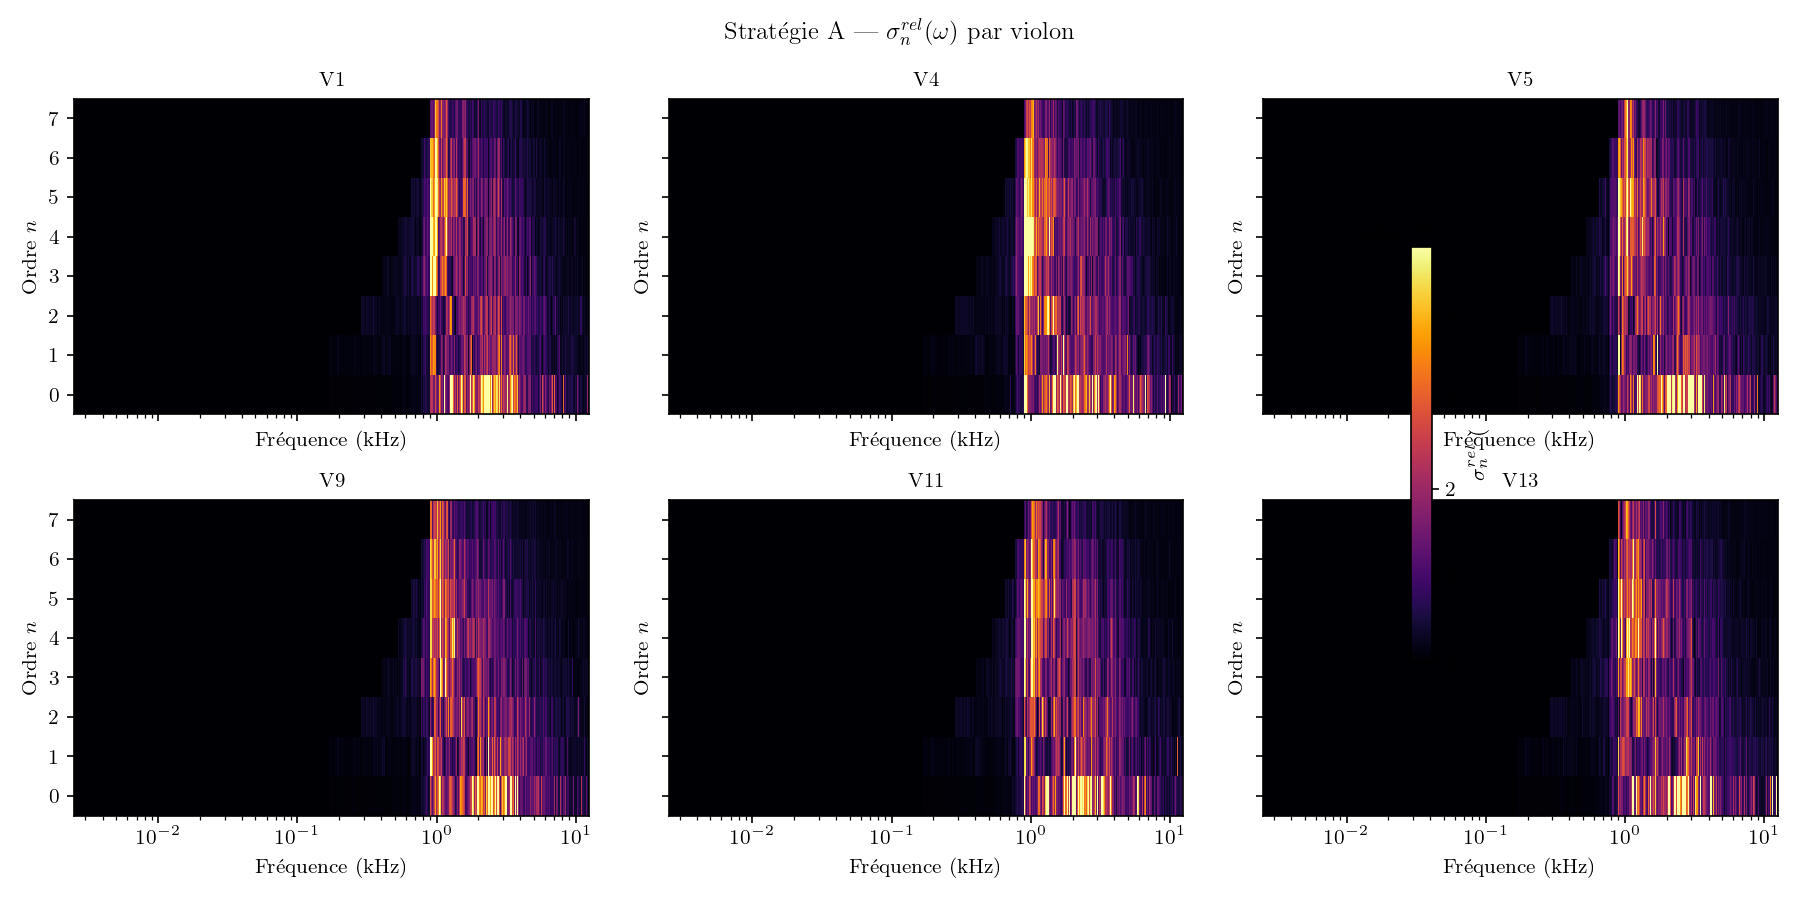

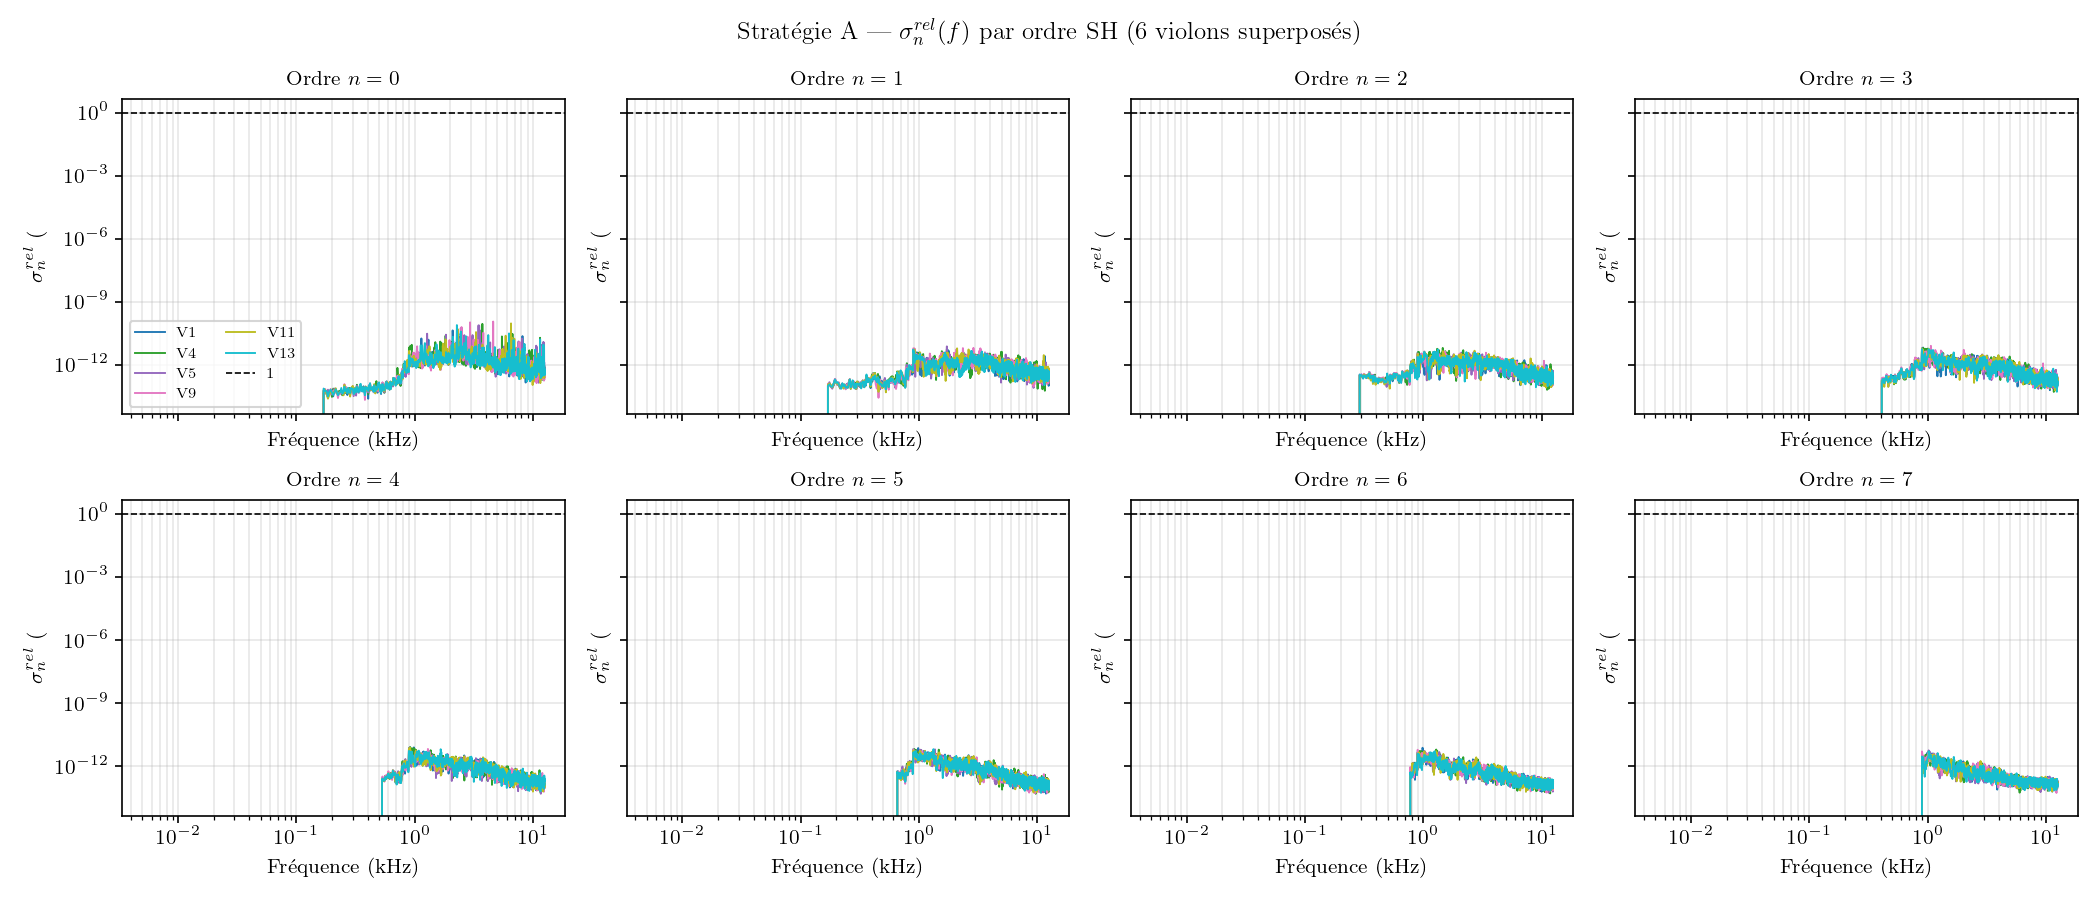

AttributeError: 'list' object has no attribute 'get_figure'

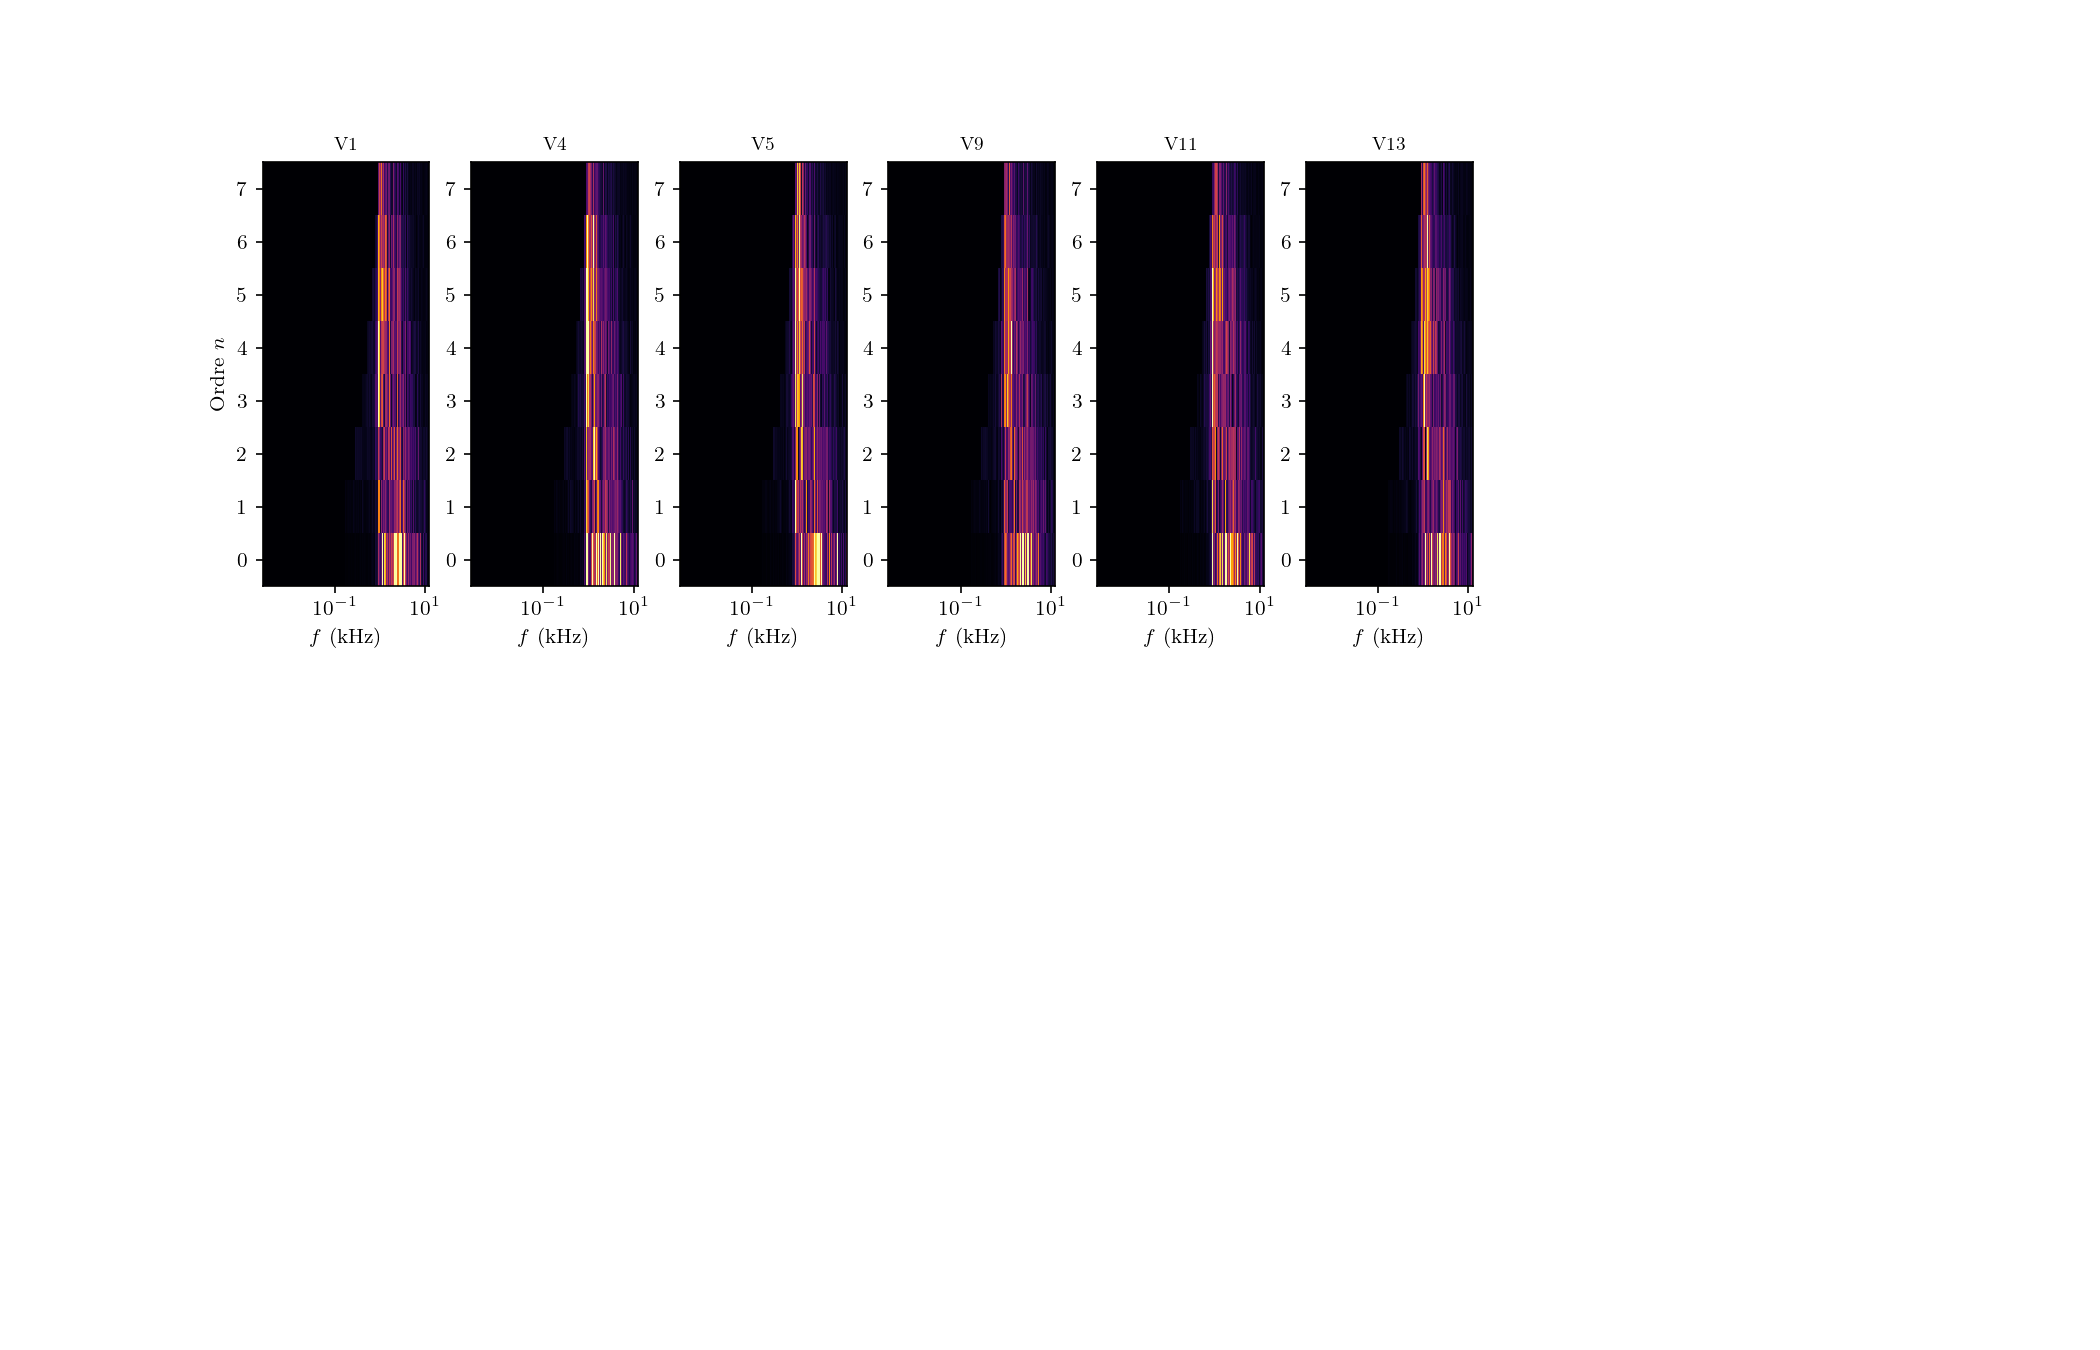

In [ ]:
# ============================================================
# STRATÉGIE A — Figure 2 : σ_n^rel heatmaps + courbes par ordre
# Figure Robustness_SigmaN.pdf
# ============================================================
violin_labels = [f'V{NumViolon[v]}' for v in range(NbViolToProcess)]
f_kHz = f / 1e3
vmax  = np.percentile(sigma_n_rel * 100, 99)   # colorscale in %

# ---- Heatmaps (NbViol panels) --------------------------------
fig1, axes1 = plt.subplots(2, 3, figsize=(12, 6), sharey=True, sharex=True)
for v, ax in enumerate(axes1.flat):
    im = ax.pcolormesh(f_kHz, np.arange(OSH + 1),
                       sigma_n_rel[v] * 100,
                       cmap='inferno', vmin=0, vmax=vmax,
                       shading='auto')
    ax.set_title(violin_labels[v], fontsize=10)
    ax.set_xlabel('Fréquence (kHz)')
    ax.set_ylabel('Ordre $n$')
    ax.set_xscale('log')
    ax.set_xlim(100, 12500)
    ax.set_yticks(np.arange(OSH + 1))
fig1.colorbar(im, ax=axes1.ravel().tolist(),
              label=r'$\sigma_n^{rel}$ (%)', shrink=0.6)
fig1.suptitle(r'Stratégie A — $\sigma_n^{rel}(\omega)$ par violon',
              fontsize=12)
plt.tight_layout()
plt.savefig('../results/Figures/StratA_sigma_heatmaps.pdf', dpi=300)
plt.show()

# ---- Courbes par ordre (6 violons superposés) ----------------
colors = plt.cm.tab10(np.linspace(0, 1, NbViolToProcess))
fig2, axes2 = plt.subplots(2, 4, figsize=(14, 6),
                            sharey=True, sharex=True)
axes2_flat = axes2.flat
for n in range(OSH + 1):
    ax = next(axes2_flat)
    for v in range(NbViolToProcess):
        ax.semilogy(f_kHz, sigma_n_rel[v, n, :] * 100,
                    lw=0.9, color=colors[v], label=violin_labels[v])
    ax.axhline(1.0, ls='--', color='k', lw=0.8, label='1 %')
    ax.set_title(f'Ordre $n={n}$')
    ax.set_xlabel('Fréquence (kHz)')
    ax.set_ylabel(r'$\sigma_n^{rel}$ (%)')
    ax.set_xscale('log')
    ax.set_xlim(100, 12500)
    ax.grid(True, which='both', alpha=0.3)
    if n == 0:
        ax.legend(fontsize=7, ncol=2)

# Hide unused panel if OSH+1 < 8
for ax in list(axes2_flat):
    ax.set_visible(False)

fig2.suptitle(r'Stratégie A — $\sigma_n^{rel}(f)$ par ordre SH '
              r'(6 violons superposés)', fontsize=12)
plt.tight_layout()
plt.savefig('../results/Figures/StratA_sigma_curves.pdf', dpi=300)
plt.show()

# ---- Combined PDF (Robustness_SigmaN.pdf) --------------------
# Heatmaps top row + per-order curves bottom row (JASA figure)
fig3 = plt.figure(figsize=(14, 9))
gs  = fig3.add_gridspec(2, max(NbViolToProcess, OSH + 1),
                         hspace=0.45, wspace=0.25)
# Top row: heatmaps
for v in range(NbViolToProcess):
    ax = fig3.add_subplot(gs[0, v])
    im = ax.pcolormesh(f_kHz, np.arange(OSH + 1),
                       sigma_n_rel[v] * 100,
                       cmap='inferno', vmin=0, vmax=vmax,
                       shading='auto')
    ax.set_title(violin_labels[v], fontsize=9)
    ax.set_xscale('log')
    ax.set_xlim(100, 12500)
    ax.set_yticks(np.arange(OSH + 1))
    if v == 0:
        ax.set_ylabel('Ordre $n$')
    ax.set_xlabel('$f$ (kHz)')
plt.colorbar(im, ax=[fig3.axes[:NbViolToProcess]],
             label=r'$\sigma_n^{rel}$ (%)', shrink=0.7, pad=0.02)

# Bottom row: per-order curves
for n in range(OSH + 1):
    ax = fig3.add_subplot(gs[1, n])
    for v in range(NbViolToProcess):
        ax.semilogy(f_kHz, sigma_n_rel[v, n, :] * 100,
                    lw=0.8, color=colors[v])
    ax.axhline(1.0, ls='--', color='k', lw=0.8)
    ax.set_title(f'$n={n}$', fontsize=9)
    ax.set_xscale('log')
    ax.set_xlim(100, 12500)
    ax.set_xlabel('$f$ (kHz)')
    if n == 0:
        ax.set_ylabel(r'$\sigma_n^{rel}$ (%)')
    ax.grid(True, which='both', alpha=0.3)

fig3.suptitle(r'\textbf{Robustness — Strategy A}: '
              r'$\sigma_n^{rel}(\omega)$', fontsize=13)
plt.savefig('../results/Figures/Robustness_SigmaN.pdf', dpi=300)
plt.show()
print("Saved: ../results/Figures/Robustness_SigmaN.pdf")

### Conclusion Stratégie A

| Grandeur | Valeur obtenue | Interprétation |
|---|---|---|
| $\sigma_n^{rel}$ tous ordres, toutes fréq. | $\sim 10^{-14}$–$10^{-15}$ | Précision arithmétique float64 |
| Convergence (Δσ/σ) | exactement 0 dès le 1er batch | Identité algébrique, pas de variabilité |
| Profil $\sigma_n^{rel}(n)$ | décroissant | Hiérarchie énergétique des ordres, pas un effet physique |

**Ce que confirme la Stratégie A :**

1. **Rotation-équivariance** de la chaîne HELS : la régularisation commute avec
   les matrices de Wigner → $E_n$ est un invariant exact de la décomposition.
2. **Correction numérique** de l'implémentation Wigner-D (Tests 1–5 de la
   validation, Étape 6).
3. **Indépendance** des $E_n$ vis-à-vis du choix arbitraire de l'orientation
   du repère SH pour cet array parallélépipédique — résultat directement
   mentionnable dans la section Méthodes de l'article JASA.

**Ce que la Stratégie A ne mesure PAS :**
La sensibilité de $\kappa(\mathbf{H})$ à l'orientation de la base (→ Stratégie B)
et la robustesse des $E_n$ au bruit de mesure (→ bootstrap sur les 5 impacts,
hors du périmètre de ce notebook).

## Stratégie B — Carte du nombre de conditionnement $\kappa(R,\omega)$ sur $SO(3)$

Pour chaque rotation $R$ et chaque fréquence $\omega$, le nombre de
conditionnement de la matrice d'inversion HELS est :

$$\kappa(R,\omega) = \frac{\sigma_{\max}(\mathbf{H}(R,\omega))}
                          {\sigma_{\min}(\mathbf{H}(R,\omega))}$$

On calcule :
- $\bar\kappa(\omega) = \mathbb{E}_{R}[\kappa]$ et
  $\Delta\kappa(\omega) = \max_R\kappa - \min_R\kappa$ (en fonction de la fréquence)
- La projection Aitoff de $\kappa(R,\omega_0)$ à trois fréquences de référence
- $R^\star(\omega) = \arg\min_R \kappa(R,\omega)$ : orientation optimale

Le rapport $\Delta\kappa/\bar\kappa$ quantifie la sensibilité du
conditionnement à l'orientation de la base. Une valeur élevée signifie
que le choix de la base SH influe significativement sur la qualité de
l'inversion pour l'antenne parallélépipédique utilisée.

In [ ]:
# ============================================================
# STRATÉGIE B — Carte de kappa(R, omega) sur SO(3)
# ============================================================
# Fréquences de référence pour les projections Aitoff
# (choisir A0 ~280Hz, B1+ ~550Hz, 3kHz)
f_ref_Hz  = [280., 550., 3000.]
f_ref_idx = [np.argmin(np.abs(f - fr)) for fr in f_ref_Hz]
f_ref_labels = [f'{fr:.0f} Hz' for fr in f_ref_Hz]

# Grille d'orientations sur SO(3) via angles d'Euler ZYZ
# beta (colatitude de l'axe z tourné) échantillonné avec poids sin(beta)
N_alpha = 24     # azimut alpha in [0, 2pi)
N_beta  = 12     # colatitude beta in [0, pi]
N_gamma = 1      # gamma: rotation propre — kappa invariant par gamma
# (kappa ne dépend que de la direction du z-axis tourné, pas de gamma,
#  car la SVD de H est invariante par rotation dans le sous-espace colonne)

alphas = np.linspace(0, 2 * np.pi, N_alpha, endpoint=False)
betas  = np.arccos(np.linspace(1, -1, N_beta))   # Haar-correct
Rots_grid = []
PhB_grid, ThB_grid = [], []
for alpha in alphas:
    for beta in betas:
        R_ab = get_rotation_matrix(alpha, beta)
        Rots_grid.append(R_ab)
        PhB_grid.append(alpha)
        ThB_grid.append(beta)

N_rots = len(Rots_grid)
print(f"Grille SO(3) : {N_rots} orientations")

# --- Calcul de kappa pour chaque orientation et chaque fréquence ---
# On calcule H(R,omega) = H0(omega) @ D(R)  [forme (NbMics, NbSH)]
# et sa SVD pour obtenir sigma_max / sigma_min

# Pour limiter le coût, on utilise une fréquence réduite
# (toutes les fréquences sur 1/3-octave uniquement pour kappa moyen)
# et toutes les fréquences pour les fréquences de référence.

from joblib import Parallel, delayed

def kappa_single_rotation(R, Ho2f0_2d_list):
    """
    Ho2f0_2d_list : list of 2D arrays H0[:, :] at selected frequencies
    Returns kappa (float array, len = nb of selected freqs)
    """
    DR = wigner_D_full_complex(R, OSH)
    kappas = []
    for H0_f in Ho2f0_2d_list:
        HR_f = H0_f @ DR                      # (NbMics, NbSH)
        sv   = np.linalg.svd(HR_f, compute_uv=False)
        kappas.append(sv[0] / sv[-1])
    return np.array(kappas)

# Extraire H0 aux fréquences de référence + grille 1/3-oct
f_thirds = f[::max(1, Nbf // 30)]            # ~30 fréquences
idx_thirds = np.where(np.isin(f, f_thirds))[0]
idx_all_ref = np.unique(np.concatenate([f_ref_idx, idx_thirds.tolist()]))

H0_slices = [Ho2f0[:, :, fi] for fi in idx_all_ref]  # list of (NbMics, NbSH)

print("Calcul des nombres de conditionnement...")
kappa_grid = np.array(
    Parallel(n_jobs=-1)(
        delayed(kappa_single_rotation)(R, H0_slices)
        for R in Rots_grid
    )
)   # shape (N_rots, len(idx_all_ref))

# Statistiques sur SO(3) pour chaque fréquence sélectionnée
kappa_mean   = kappa_grid.mean(axis=0)
kappa_min    = kappa_grid.min(axis=0)
kappa_max    = kappa_grid.max(axis=0)
kappa_spread = kappa_max - kappa_min
f_sel        = f[idx_all_ref]

# Orientation optimale (argmin kappa) à chaque fréquence de référence
opt_idx = {}
for k, fi in enumerate(f_ref_idx):
    col = np.where(idx_all_ref == fi)[0][0]
    opt_rot_i = int(np.argmin(kappa_grid[:, col]))
    opt_idx[fi] = {
        'R': Rots_grid[opt_rot_i],
        'alpha': PhB_grid[opt_rot_i],
        'beta': ThB_grid[opt_rot_i],
        'kappa_opt': kappa_grid[opt_rot_i, col],
        'kappa_ref': kappa_grid[0, col],   # orientation de référence (lab frame)
    }
    print(f"  f={f_ref_Hz[k]:.0f} Hz | kappa_opt={opt_idx[fi]['kappa_opt']:.2f}"
          f" | kappa_ref={opt_idx[fi]['kappa_ref']:.2f}"
          f" | gain={opt_idx[fi]['kappa_ref']/opt_idx[fi]['kappa_opt']:.2f}x")

print("Calcul terminé.")

Grille SO(3) : 288 orientations
Calcul des nombres de conditionnement...
  f=280 Hz | kappa_opt=41380.45 | kappa_ref=41380.45 | gain=1.00x
  f=550 Hz | kappa_opt=543.37 | kappa_ref=543.37 | gain=1.00x
  f=3000 Hz | kappa_opt=15.47 | kappa_ref=15.47 | gain=1.00x
Calcul terminé.


FileNotFoundError: [Errno 2] No such file or directory: './Figures/Robustness_Kappa.pdf'

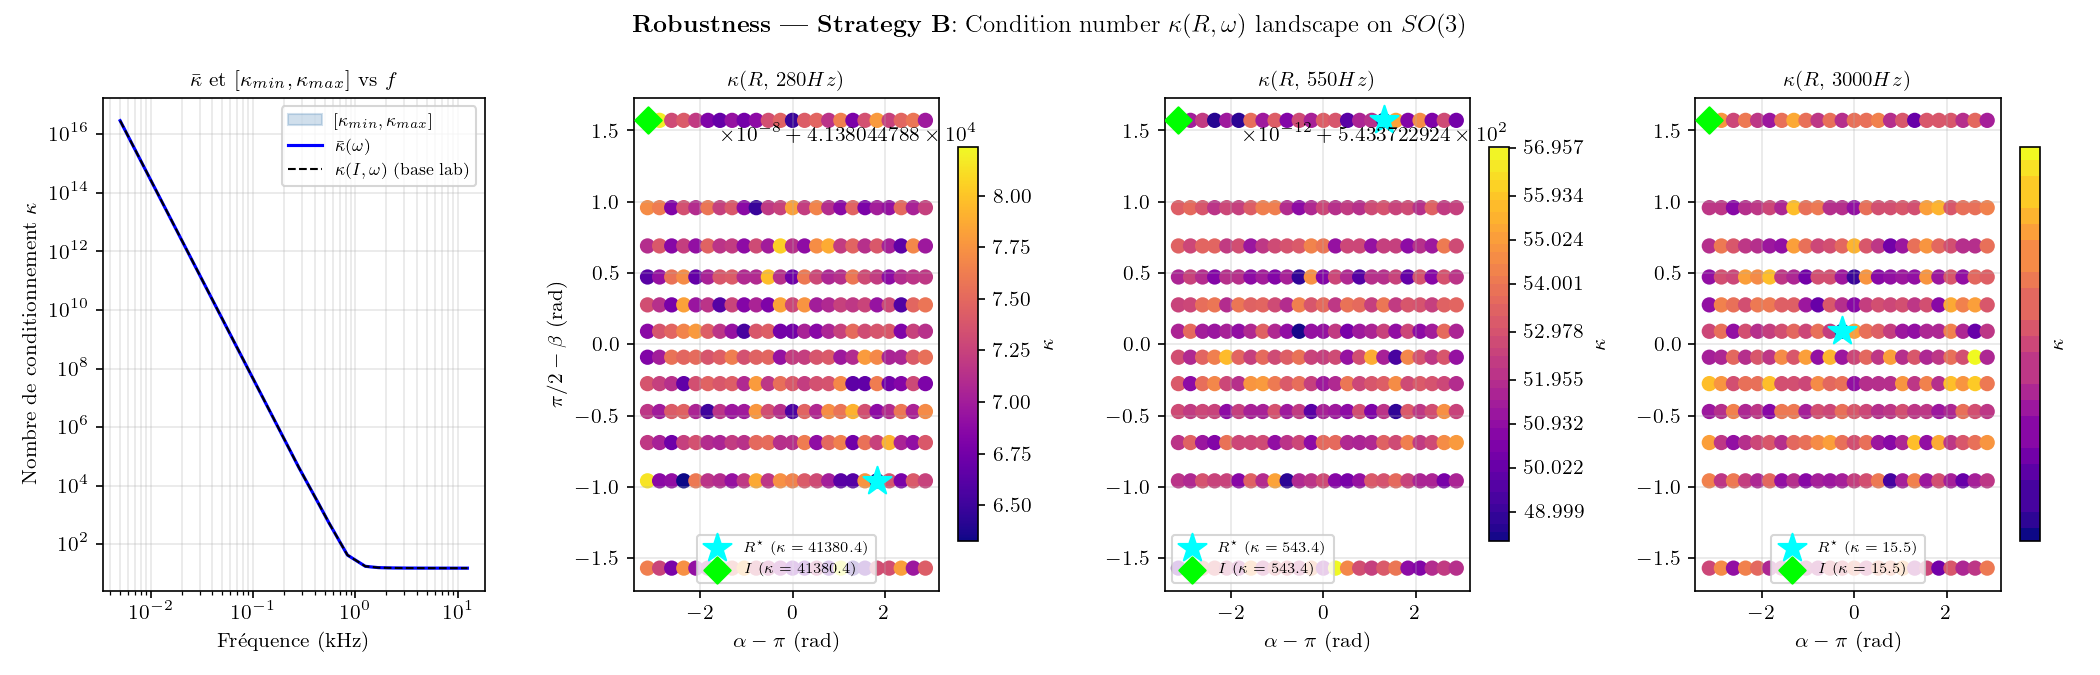

In [ ]:
# ============================================================
# STRATÉGIE B — Figures
# Figure Robustness_Kappa.pdf
# ============================================================

fig, axes = plt.subplots(1, 1 + len(f_ref_Hz), figsize=(14, 4.5))

# ---- Panneau gauche : kappa_mean ± spread vs fréquence ------
ax0 = axes[0]
ax0.fill_between(f_sel / 1e3, kappa_min, kappa_max,
                 alpha=0.25, color='steelblue', label=r'$[\kappa_{min},\kappa_{max}]$')
ax0.semilogy(f_sel / 1e3, kappa_mean, 'b-', lw=1.5,
             label=r'$\bar\kappa(\omega)$')
# kappa au lab-frame (R = I, index 0 dans Rots_grid)
ax0.semilogy(f_sel / 1e3, kappa_grid[0, :], 'k--', lw=1,
             label=r'$\kappa(I,\omega)$ (base lab)')
ax0.set_xlabel('Fréquence (kHz)')
ax0.set_ylabel(r'Nombre de conditionnement $\kappa$')
ax0.set_xscale('log')
ax0.set_title(r'$\bar\kappa$ et $[\kappa_{min},\kappa_{max}]$ vs $f$')
ax0.legend(fontsize=8)
ax0.grid(True, which='both', alpha=0.3)

# ---- Panneaux droits : Aitoff de kappa(R, omega_0) ----------
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Reshape kappa_grid -> (N_alpha, N_beta) pour chaque f_ref
AlphaG = np.array(PhB_grid).reshape(N_alpha, N_beta)
BetaG  = np.array(ThB_grid).reshape(N_alpha, N_beta)

# Aitoff: longitude = alpha - pi, latitude = pi/2 - beta
lon = AlphaG - np.pi
lat = np.pi / 2 - BetaG

for k, (fi, fr_label) in enumerate(zip(f_ref_idx, f_ref_labels)):
    col = np.where(idx_all_ref == fi)[0][0]
    kappa_map = kappa_grid.reshape(N_alpha, N_beta)[:, :, ] if False else \
                kappa_grid[:, col].reshape(N_alpha, N_beta)

    ax = axes[k + 1]
    # Scatter Aitoff (matplotlib Aitoff projection requires a dedicated axes)
    # Here we use a flat Aitoff-like scatter for simplicity
    sc = ax.scatter(lon.ravel(), lat.ravel(),
                    c=kappa_map.ravel(), cmap='plasma',
                    s=40, vmin=kappa_min[col], vmax=kappa_max[col])
    # Mark optimal orientation
    oi = opt_idx[fi]
    ax.scatter(oi['alpha'] - np.pi, np.pi / 2 - oi['beta'],
               marker='*', s=200, c='cyan', zorder=5,
               label=fr'$R^\star$ ($\kappa={oi["kappa_opt"]:.1f}$)')
    # Mark lab frame (alpha=0, beta=0 → lon=-pi, lat=pi/2)
    ax.scatter(-np.pi, np.pi / 2, marker='D', s=80, c='lime', zorder=5,
               label=fr'$I$ ($\kappa={oi["kappa_ref"]:.1f}$)')
    ax.set_title(fr'$\kappa(R,\,{fr_label})$', fontsize=10)
    ax.set_xlabel(r'$\alpha - \pi$ (rad)')
    if k == 0:
        ax.set_ylabel(r'$\pi/2 - \beta$ (rad)')
    plt.colorbar(sc, ax=ax, shrink=0.8, label=r'$\kappa$')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle(r'\textbf{Robustness — Strategy B}: '
             r'Condition number $\kappa(R,\omega)$ landscape on $SO(3)$',
             fontsize=12)
plt.tight_layout()
plt.savefig('./Figures/Robustness_Kappa.pdf', dpi=300)
plt.show()

# --- Panneau complémentaire : Δkappa/kappa_mean vs f ----------
fig2, ax2 = plt.subplots(figsize=(6, 3.5))
rel_spread = kappa_spread / np.maximum(kappa_mean, 1e-6)
ax2.semilogx(f_sel / 1e3, rel_spread, 'k-', lw=1.5)
ax2.axhline(0.5, ls='--', color='r', lw=0.8, label='50 %')
ax2.set_xlabel('Fréquence (kHz)')
ax2.set_ylabel(r'$\Delta\kappa / \bar\kappa$')
ax2.set_title(r'Sensibilité relative de $\kappa$ à l\'orientation de la base')
ax2.legend(fontsize=9)
ax2.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('./Figures/StratB_kappa_spread.pdf', dpi=300)
plt.show()

print("Saved: Figures/Robustness_Kappa.pdf")
print("Saved: Figures/StratB_kappa_spread.pdf")